In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data (note the .. because notebooks/ is one level deep)
prices = pd.read_parquet("../data/sp500_prices.parquet")
tickers = prices.columns.get_level_values(0).unique()

print(f"Loaded {len(tickers)} stocks")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

Loaded 501 stocks
Date range: 2020-01-02 to 2024-12-31


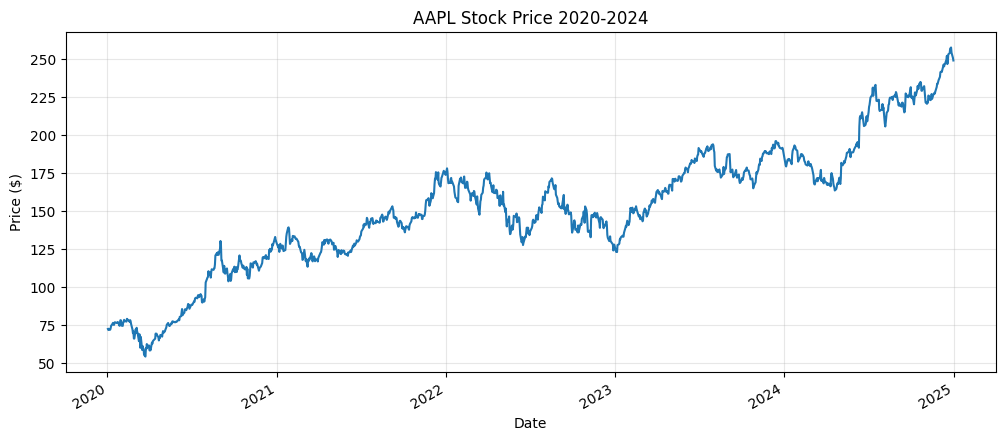

In [2]:
ticker = 'AAPL'
prices[ticker]['Close'].plot(figsize=(12, 5), title=f"{ticker} Stock Price 2020-2024")
plt.ylabel("Price ($)")
plt.grid(alpha=0.3)
plt.show()

=== AAPL Statistics ===
Daily mean return:    0.1182%
Daily volatility:     1.9956%
Annualized return:    29.79%
Annualized vol:       31.68%
Sharpe ratio (rf=0):  0.94
Best day:             11.98%
Worst day:            -12.86%


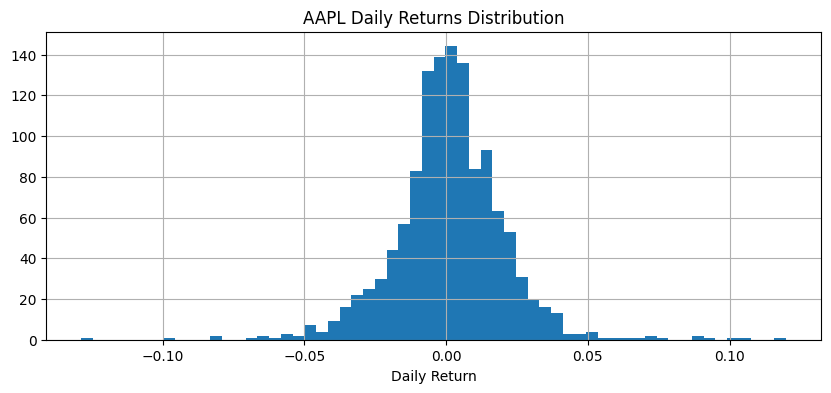

In [3]:
returns = prices[ticker]['Close'].pct_change().dropna()

print(f"=== {ticker} Statistics ===")
print(f"Daily mean return:    {returns.mean():.4%}")
print(f"Daily volatility:     {returns.std():.4%}")
print(f"Annualized return:    {returns.mean() * 252:.2%}")
print(f"Annualized vol:       {returns.std() * np.sqrt(252):.2%}")
print(f"Sharpe ratio (rf=0):  {returns.mean() / returns.std() * np.sqrt(252):.2f}")
print(f"Best day:             {returns.max():.2%}")
print(f"Worst day:            {returns.min():.2%}")

returns.hist(bins=60, figsize=(10, 4))
plt.title(f"{ticker} Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.show()

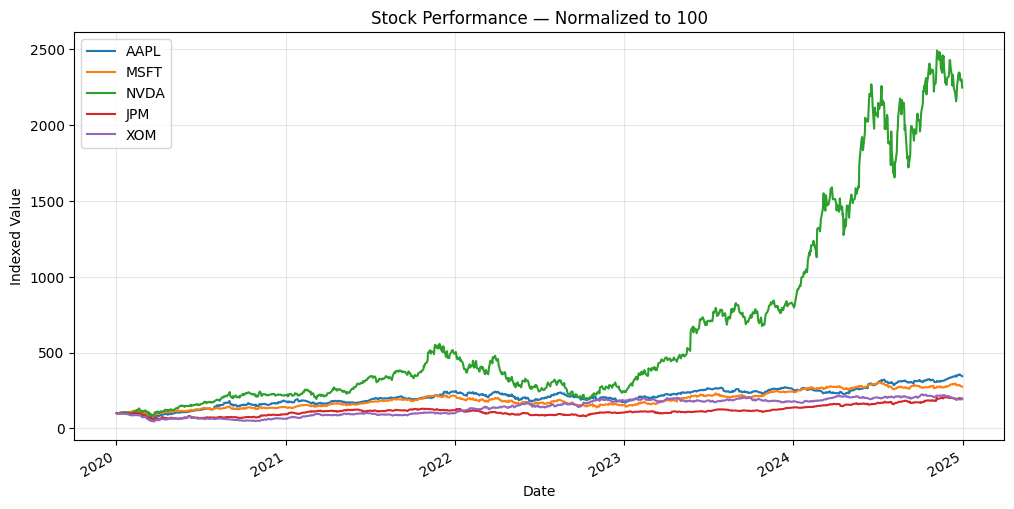


Total return over period:
  AAPL: +244.0%
  MSFT: +174.4%
  NVDA: +2148.4%
  JPM: +96.3%
  XOM: +93.4%


In [4]:
to_compare = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
to_compare = [t for t in to_compare if t in tickers]  # only use ones we have

closes = pd.DataFrame({t: prices[t]['Close'] for t in to_compare})

# Normalize to 100 at start so they're comparable
normalized = closes / closes.iloc[0] * 100
normalized.plot(figsize=(12, 6), title="Stock Performance — Normalized to 100")
plt.ylabel("Indexed Value")
plt.grid(alpha=0.3)
plt.show()

# Show total return for each
print("\nTotal return over period:")
for t in to_compare:
    total_return = (closes[t].iloc[-1] / closes[t].iloc[0] - 1) * 100
    print(f"  {t}: {total_return:+.1f}%")

In [5]:
# Compute total return for every stock
total_returns = {}
for t in tickers:
    closes = prices[t]['Close'].dropna()
    if len(closes) > 0:
        total_returns[t] = (closes.iloc[-1] / closes.iloc[0] - 1) * 100

returns_df = pd.Series(total_returns).sort_values(ascending=False)

print("=== Top 10 performers (2020-2024) ===")
print(returns_df.head(10).round(1))

print("\n=== Bottom 10 performers (2020-2024) ===")
print(returns_df.tail(10).round(1))

=== Top 10 performers (2020-2024) ===
NVDA    2148.4
TSLA    1307.9
SMCI    1189.9
VRT      916.1
FIX      788.0
ANET     763.9
AVGO     728.4
PLTR     696.1
PWR      678.6
AXON     676.3
dtype: float64

=== Bottom 10 performers (2020-2024) ===
SATS   -47.0
BIIB   -48.0
DG     -48.7
CCL    -50.9
NCLH   -56.3
EL     -61.4
BAX    -62.5
INTC   -62.6
WBD    -67.2
PSKY   -71.3
dtype: float64
